In [ ]:
# install libraries
!pip install catboost
!pip install xgboost
!pip install imblearn
# install libraries
%pip install catboost
%pip install xgboost
%pip install imblearn
%pip install rdkit

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import CategoricalNB
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier, Pool
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import VotingClassifier, BaggingClassifier
from sklearn.utils._param_validation import generate_valid_param, validate_parameter_constraints
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFECV
from rdkit import Chem
from rdkit.Chem import Descriptors
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Data Preprocessing

In [2]:
# read dataset
df = pd.read_csv('apistox_dataset.csv')
df

,name,CID,CAS,SMILES,source,year,toxicity_type,herbicide,fungicide,insecticide,other_agrochemical,label,ppdb_level
0,Ethanedioic acid,971,144-62-7,O=C(O)C(=O)O,ECOTOX,1832,Contact,0,0,0,0,0,0
1,Para-cymene,7463,99-87-6,Cc1ccc(C(C)C)cc1,BPDB,1833,Other,0,0,0,1,0,1
2,Kieselguhr,24261,61790-53-2,O=[Si]=O,ECOTOX,1833,Contact,0,0,0,0,0,0
3,Benzoic acid,243,65-85-0,O=C(O)c1ccccc1,ECOTOX,1833,Contact,1,1,1,0,0,1
4,Tetradifon (Ref: ENT 23737),8305,116-29-0,O=S(=O)(c1ccc(Cl)cc1)c1cc(Cl)c(Cl)cc1Cl,PPDB,1836,Oral,0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1030,Benzyl 4-amino-3-chloro-6-(4-chloro-2-fluoro-3...,70495450,1390661-72-9,COc1c(Cl)ccc(-c2nc(C(=O)OCc3ccccc3)c(Cl)c(N)c2...,ECOTOX,2023,Contact,1,0,0,0,0,1
1031,Glyphosate-dimethylammonium,13208144,34494-04-7,CNC.O=C(O)CNCP(=O)(O)O,PPDB,2023,Contact,1,0,0,0,0,1
1032,Glyphosate-monoammonium,11615303,114370-14-8,N.O=C(O)CNCP(=O)(O)O,PPDB,2023,Contact,1,0,0,0,0,1
1033,Bixlozone (Ref: F9600),15056663,81777-95-9,CC1(C)CON(Cc2ccc(Cl)cc2Cl)C1=O,PPDB,2023,Contact,1,0,0,0,0,1


In [3]:
# check for null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                1035 non-null   object
 1   CID                 1035 non-null   int64 
 2   CAS                 1035 non-null   object
 3   SMILES              1035 non-null   object
 4   source              1035 non-null   object
 5   year                1035 non-null   int64 
 6   toxicity_type       1035 non-null   object
 7   herbicide           1035 non-null   int64 
 8   fungicide           1035 non-null   int64 
 9   insecticide         1035 non-null   int64 
 10  other_agrochemical  1035 non-null   int64 
 11  label               1035 non-null   int64 
 12  ppdb_level          1035 non-null   int64 
dtypes: int64(8), object(5)
memory usage: 105.2+ KB


In [4]:
# drop duplicates
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                1035 non-null   object
 1   CID                 1035 non-null   int64 
 2   CAS                 1035 non-null   object
 3   SMILES              1035 non-null   object
 4   source              1035 non-null   object
 5   year                1035 non-null   int64 
 6   toxicity_type       1035 non-null   object
 7   herbicide           1035 non-null   int64 
 8   fungicide           1035 non-null   int64 
 9   insecticide         1035 non-null   int64 
 10  other_agrochemical  1035 non-null   int64 
 11  label               1035 non-null   int64 
 12  ppdb_level          1035 non-null   int64 
dtypes: int64(8), object(5)
memory usage: 105.2+ KB


# EDA 1

In [ ]:
# color palette
bee_palette = [
    "#D18900",  
    "#F6C747",  
    "#FAD66B",  
    "#EDA63A",  
    "#E2853B",  s
    "#C97733",  
    "#A35A36",  
    "#6A4D3B",  
    "#4E3C34",  
    "#BF5E3B",  
]

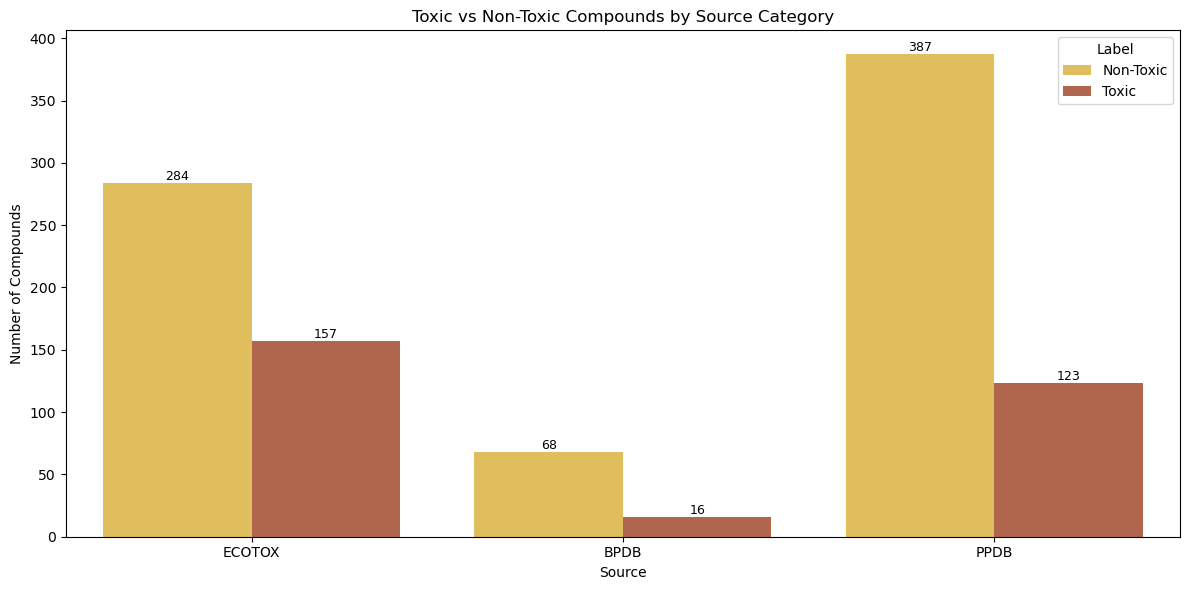

In [6]:
# Choose colors for label
custom_palette = {
    'Non-Toxic': bee_palette[1],  # "#D18900"
    'Toxic': bee_palette[9]       # "#BF5E3B"
}

# Counting number of Non-Toxic and Toxic based on "source"
data = []
sources = df['source'].unique()

for src in sources:
    non_toxic = df[(df['label'] == 0) & (df['source'] == src)].shape[0]
    toxic = df[(df['label'] == 1) & (df['source'] == src)].shape[0]
    data.append({'Source': src, 'Label': 'Non-Toxic', 'Count': non_toxic})
    data.append({'Source': src, 'Label': 'Toxic', 'Count': toxic})

plot_df = pd.DataFrame(data)

# Make Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Source', y='Count', hue='Label', palette=custom_palette)
plt.title('Toxic vs Non-Toxic Compounds by Source Category')
plt.xlabel('Source')
plt.ylabel('Number of Compounds')

# Adding number to bar
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{int(height)}',
                           (p.get_x() + p.get_width() / 2., height),
                           ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

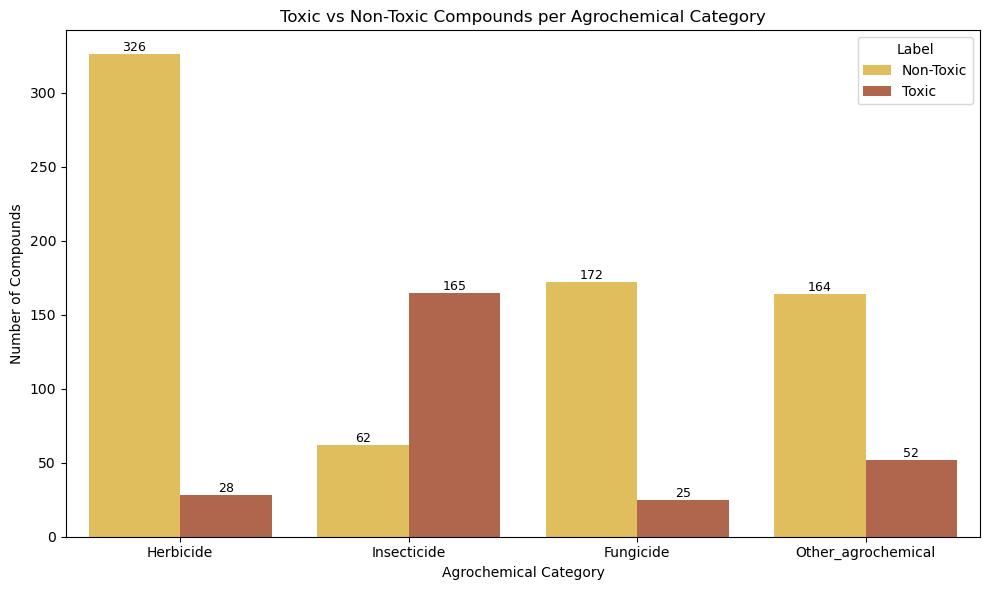

In [ ]:
# Choosing colors for label
custom_palette = {
    'Non-Toxic': bee_palette[1],  
    'Toxic': bee_palette[9]       
}

# Prepare data
categories = ['herbicide', 'insecticide', 'fungicide', 'other_agrochemical']
data = []

for cat in categories:
    non_toxic = df[df['label'] == 0][cat].sum()
    toxic = df[df['label'] == 1][cat].sum()
    data.append({'Category': cat.capitalize(), 'Label': 'Non-Toxic', 'Count': non_toxic})
    data.append({'Category': cat.capitalize(), 'Label': 'Toxic', 'Count': toxic})

plot_df = pd.DataFrame(data)

# Make Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='Category', y='Count', hue='Label', palette=custom_palette)
plt.title('Toxic vs Non-Toxic Compounds per Agrochemical Category')
plt.xlabel('Agrochemical Category')
plt.ylabel('Number of Compounds')

# Adding number to bar
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{int(height)}',
                           (p.get_x() + p.get_width() / 2., height),
                           ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

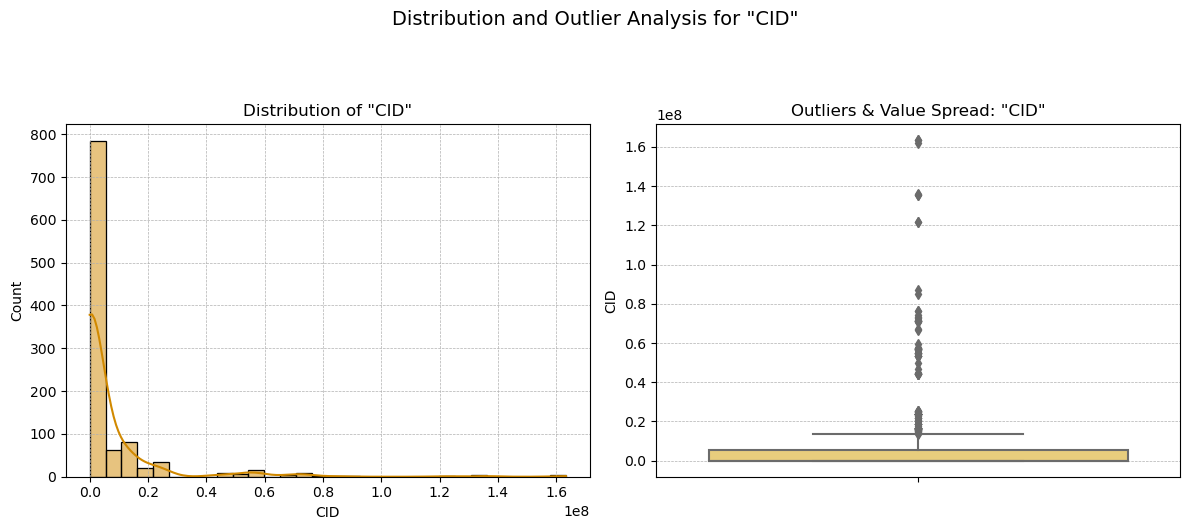

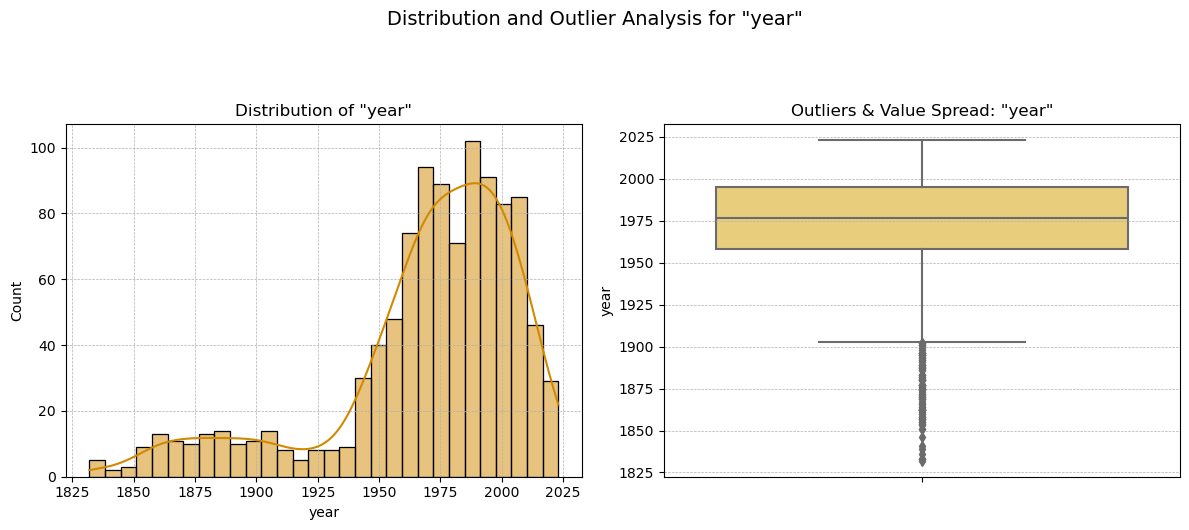

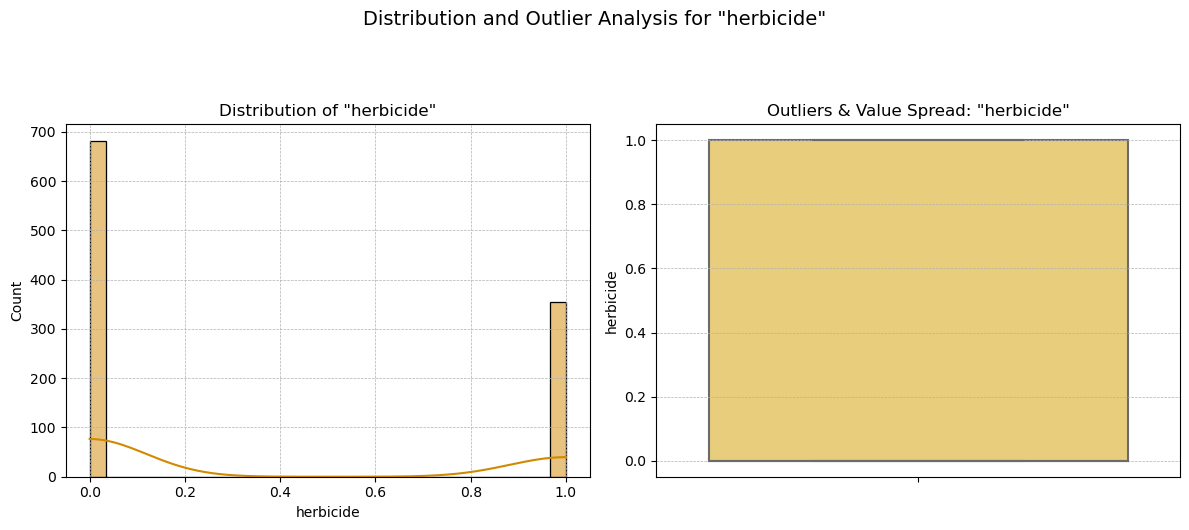

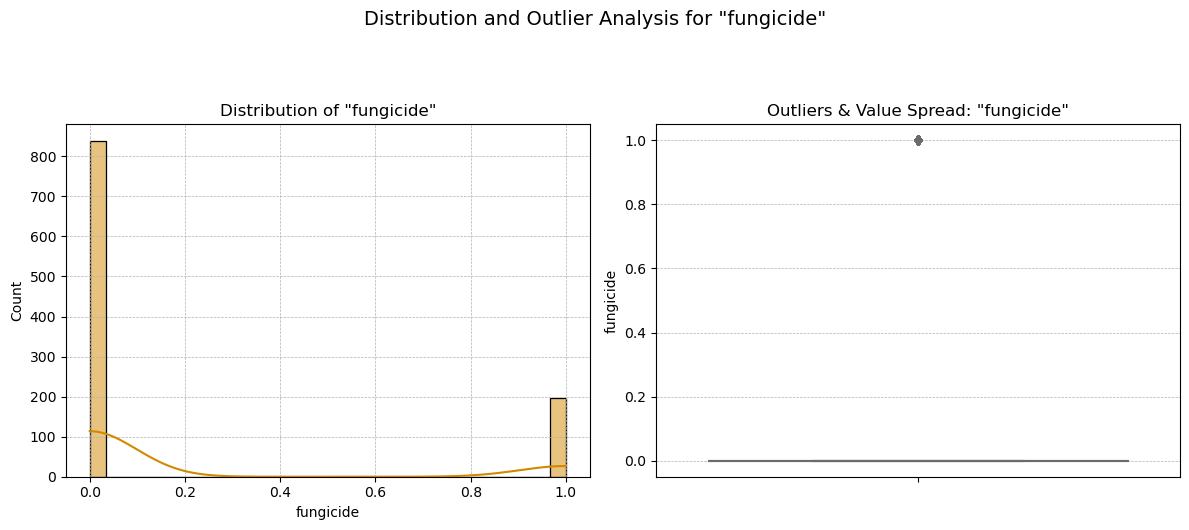

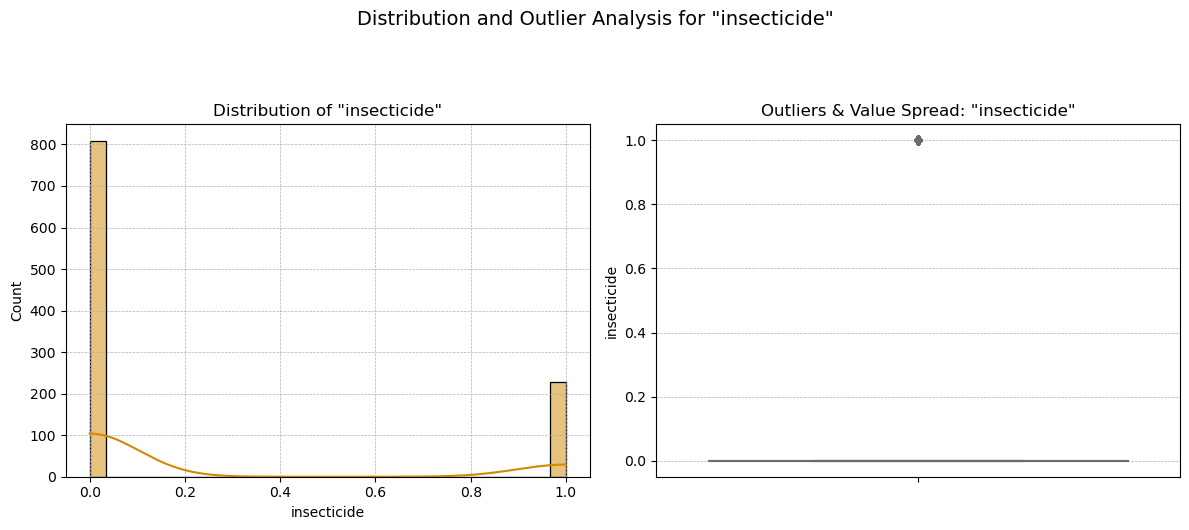

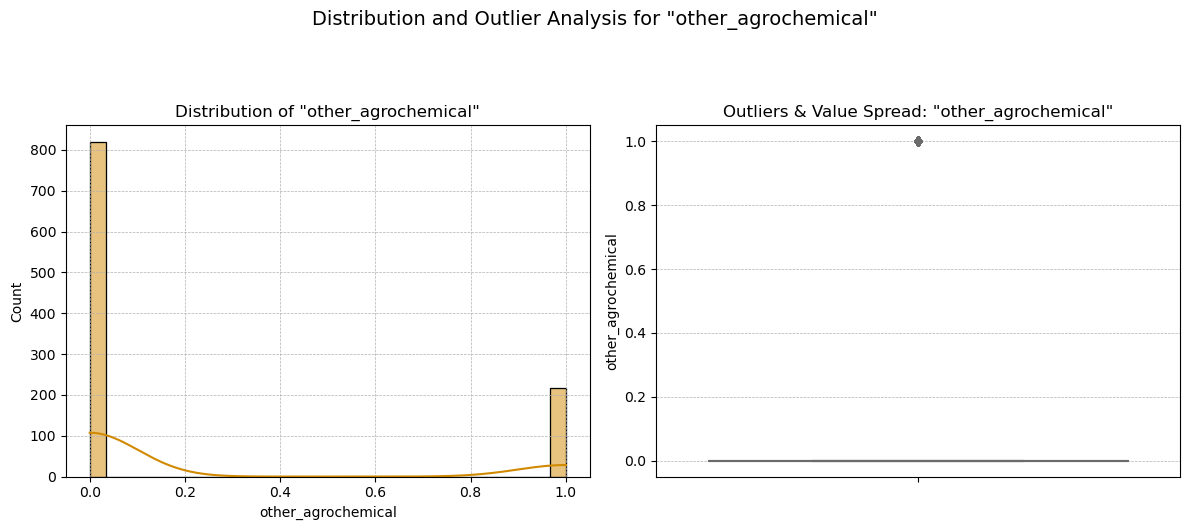

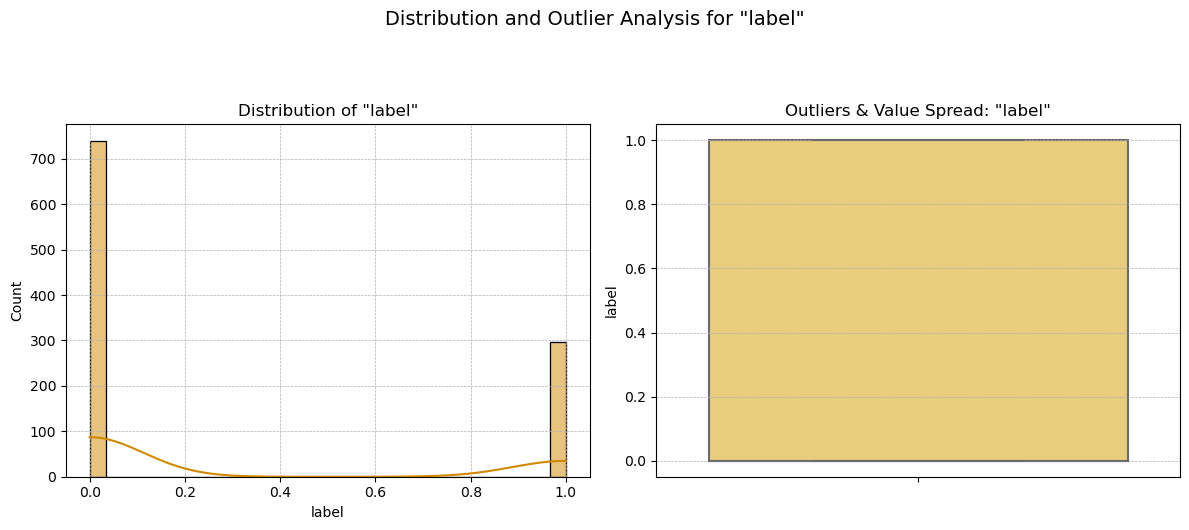

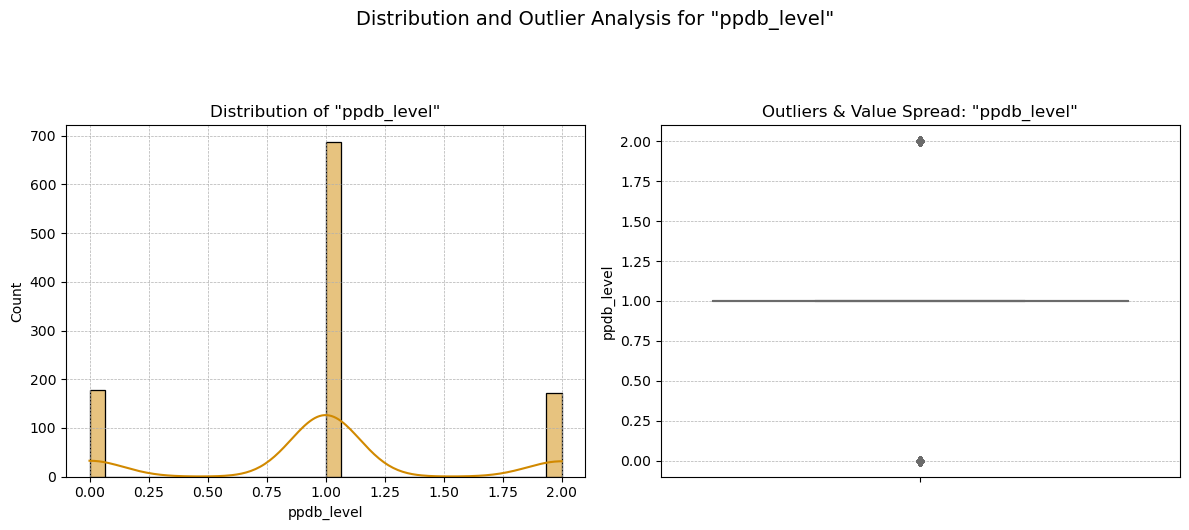

In [ ]:
hist_color = "#D18900"
box_color = "#FAD66B"

# Get numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Make plot
for col in numerical_cols:
    try:
        plt.figure(figsize=(12, 5))

        # histogram
        plt.subplot(1, 2, 1)
        sns.histplot(df[col].dropna(), kde=True, color=hist_color, bins=30)
        plt.title(f'Distribution of "{col}"')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.grid(True, linestyle='--', linewidth=0.5)

        # boxplot & outliers
        plt.subplot(1, 2, 2)
        sns.boxplot(y=df[col].dropna(), color=box_color)
        plt.title(f'Outliers & Value Spread: "{col}"')
        plt.ylabel(col)
        plt.grid(True, axis='y', linestyle='--', linewidth=0.5)

        plt.suptitle(f'Distribution and Outlier Analysis for "{col}"', fontsize=14, y=1.05)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    except Exception as e:
        print(f"Skipped column '{col}' due to error: {e}")


C:\Users\aaron\AppData\Local\Temp\ipykernel_4576\3733019961.py:44: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.95])


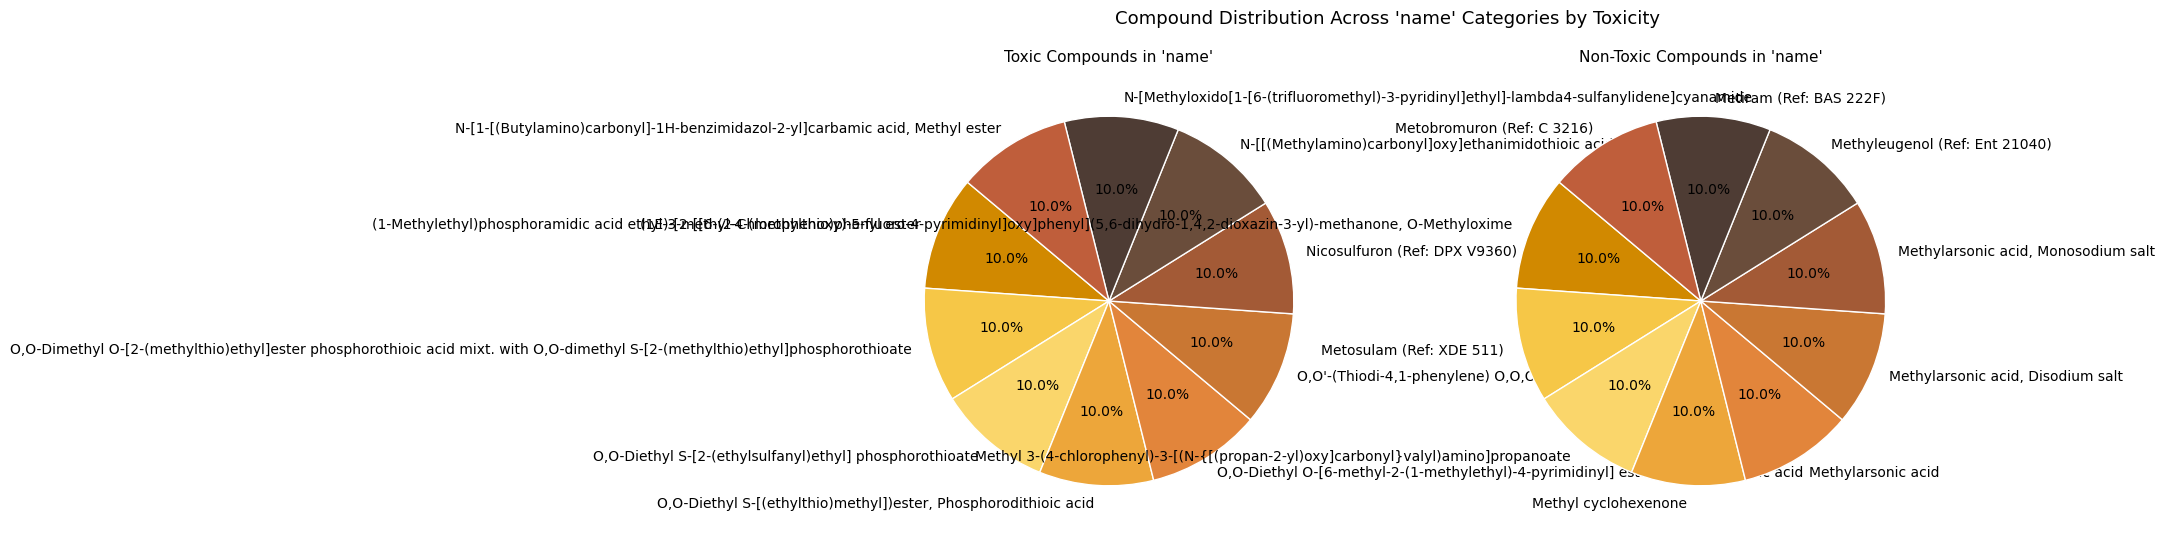

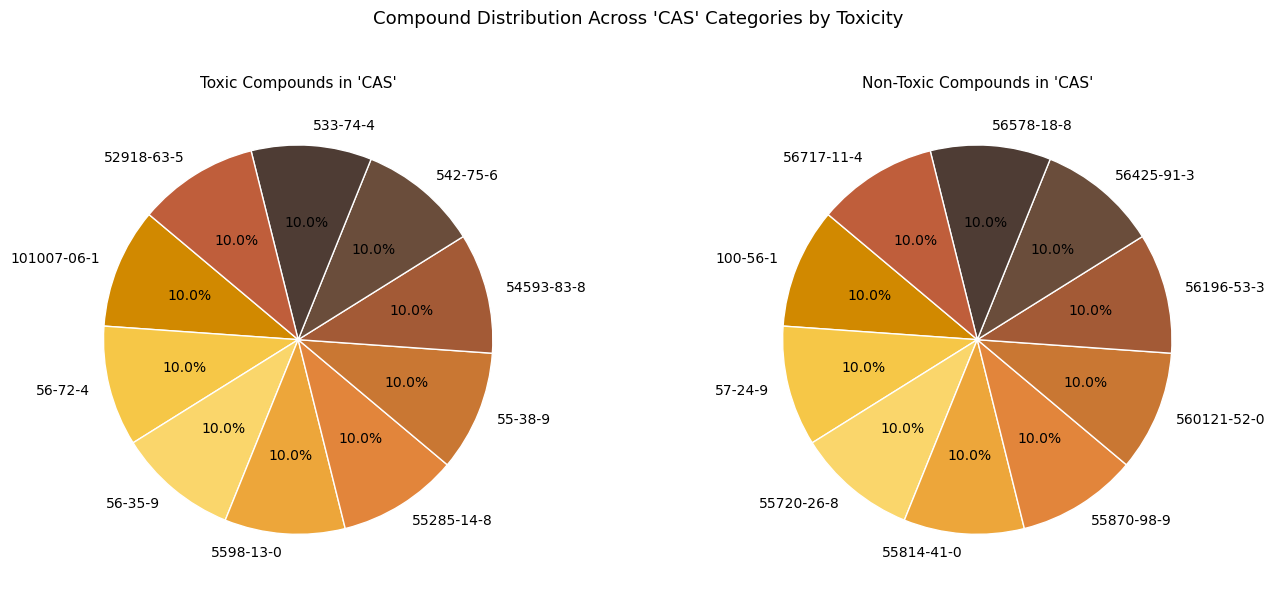

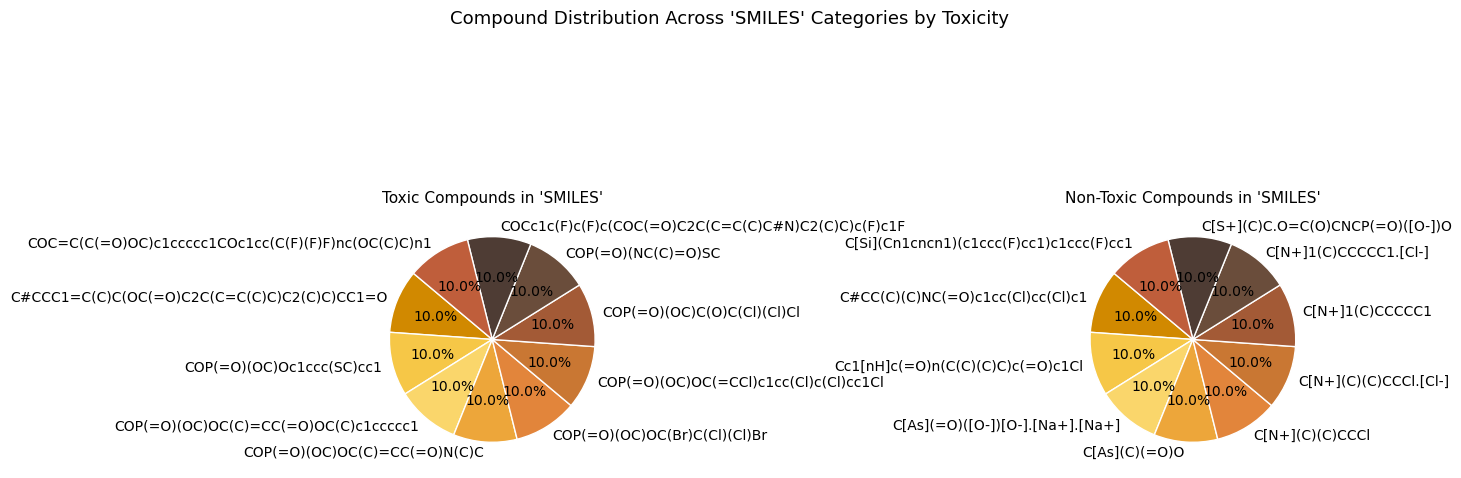

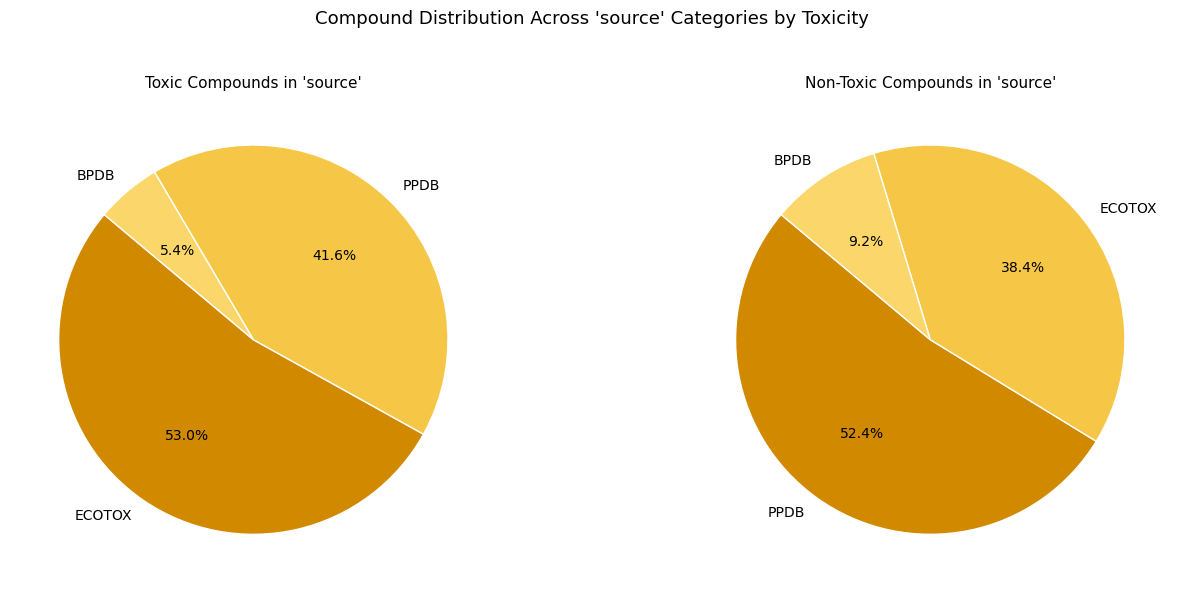

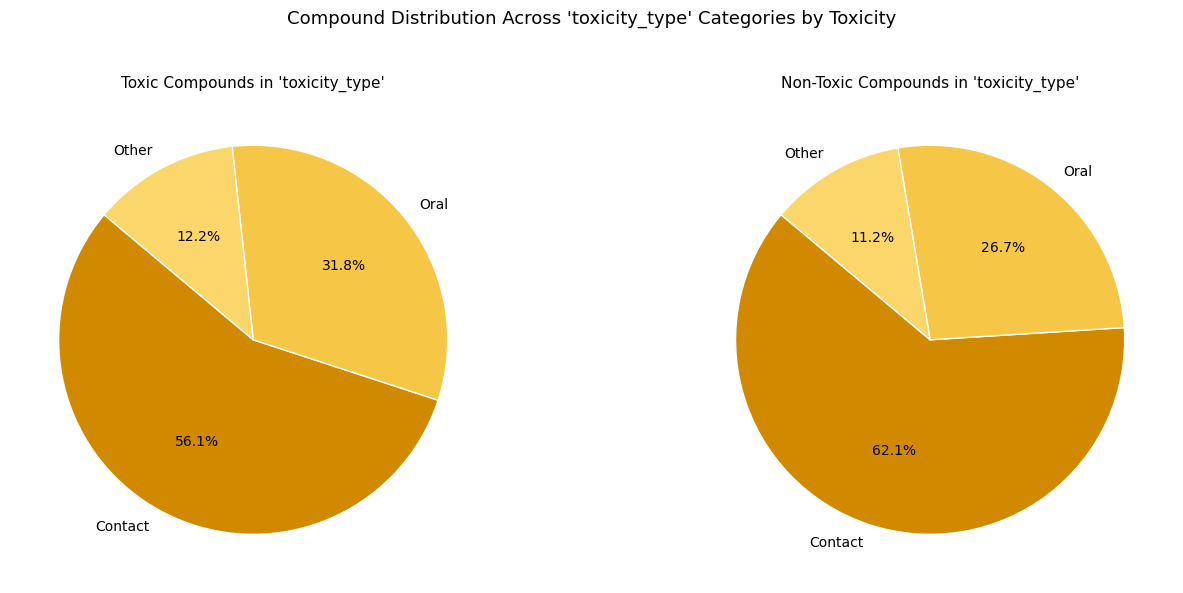

In [ ]:
# Get categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Make pie chart
for col in categorical_cols:
    try:
        # Count distributions for label: toxic (1)
        toxic_counts = df[df['label'] == 1].groupby(col)['label'].count().sort_values(ascending=False)
        if len(toxic_counts) > 10:
            toxic_counts = toxic_counts.head(10)

        # Count distributions for label: non-toxic (0)
        nontoxic_counts = df[df['label'] == 0].groupby(col)['label'].count().sort_values(ascending=False)
        if len(nontoxic_counts) > 10:
            nontoxic_counts = nontoxic_counts.head(10)

        plt.figure(figsize=(14, 6))

        plt.subplot(1, 2, 1)
        plt.pie(
            x=toxic_counts.values,
            labels=toxic_counts.index,
            autopct='%1.1f%%',
            colors=bee_palette[:len(toxic_counts)],
            startangle=140,
            wedgeprops={'edgecolor': 'white'}
        )
        plt.title(f"Toxic Compounds in '{col}'", fontsize=11)

        plt.subplot(1, 2, 2)
        plt.pie(
            x=nontoxic_counts.values,
            labels=nontoxic_counts.index,
            autopct='%1.1f%%',
            colors=bee_palette[:len(nontoxic_counts)],
            startangle=140,
            wedgeprops={'edgecolor': 'white'}
        )
        plt.title(f"Non-Toxic Compounds in '{col}'", fontsize=11)

        plt.suptitle(f"Compound Distribution Across '{col}' Categories by Toxicity", fontsize=13)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    except Exception as e:
        print(f"Skipped column '{col}' due to error: {e}")


# Feature Engineering

Feature engineering is selection, creation or transformation of features which could help improve the performance of machine learning models. In our dataset, there is one feature that quite difficult to be interpreted by models. That being the "SMILES" feature. 

SMILES is the abbreviation of Simplified Molecular Input Line Entry System which is a chemical notation that allows a user to represent a chemical structure in a way that can be used by the computer. The SMILES feature is processed using a library called RDKit which is designed to handle chemistry related stuff. Using this library, we are able to convert our SMILES feature into 5 new features that the models would easily understand. 

The features chosen are possible characteristics that allow us to identify whether a molecule is toxic or not. These new features include: 'MolWt' or molecular weight, 'TPSA' or topological polar surface area, 'NumHDonors' or number of hydrogen bond donors, 'NumHAcceptors' or number of hydrogen bond acceptors and 'MolLogP' or octanol water partition coefficient.

In [10]:
# turn SMILES column to features
def smiles_to_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {}
    return {
        'MolWt': Descriptors.MolWt(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        'MolLogP': Descriptors.MolLogP(mol),
    }

features = df['SMILES'].apply(smiles_to_features)
features_df = pd.DataFrame(features.tolist())
df = pd.concat([df, features_df], axis=1)
df = df.drop('SMILES', axis=1)

Other than creating new features, we transform categorical features by using one hot encoding. In our dataset, there is only one categorical feature that hasn't been transformed which is "toxicity_type". There are three classes in "toxicity_type": contact, oral and other. New columns for each class is created and in those columns are True or False values depending what their original class were. We also set drop_first to True which drops contact. This is to reduce the load that the model need to process which could increase its performance.

In [11]:
# encode categorical values
df = pd.get_dummies(df, columns=['toxicity_type'], drop_first=True)
df.head()

,name,CID,CAS,source,year,herbicide,fungicide,insecticide,other_agrochemical,label,ppdb_level,MolWt,TPSA,NumHDonors,NumHAcceptors,MolLogP,toxicity_type_Oral,toxicity_type_Other
0,Ethanedioic acid,971,144-62-7,ECOTOX,1832,0,0,0,0,0,0,90.034,74.60,2,2,-0.84440,False,False
1,Para-cymene,7463,99-87-6,BPDB,1833,0,0,0,1,0,1,134.222,0.00,0,0,3.11842,False,True
2,Kieselguhr,24261,61790-53-2,ECOTOX,1833,0,0,0,0,0,0,60.084,34.14,0,2,-0.61840,False,False
3,Benzoic acid,243,65-85-0,ECOTOX,1833,1,1,1,0,0,1,122.123,37.30,1,1,1.38480,False,False
4,Tetradifon (Ref: ENT 23737),8305,116-29-0,PPDB,1836,0,0,0,1,1,1,356.057,34.14,0,2,5.13300,True,False


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 1035 non-null   object 
 1   CID                  1035 non-null   int64  
 2   CAS                  1035 non-null   object 
 3   source               1035 non-null   object 
 4   year                 1035 non-null   int64  
 5   herbicide            1035 non-null   int64  
 6   fungicide            1035 non-null   int64  
 7   insecticide          1035 non-null   int64  
 8   other_agrochemical   1035 non-null   int64  
 9   label                1035 non-null   int64  
 10  ppdb_level           1035 non-null   int64  
 11  MolWt                1035 non-null   float64
 12  TPSA                 1035 non-null   float64
 13  NumHDonors           1035 non-null   int64  
 14  NumHAcceptors        1035 non-null   int64  
 15  MolLogP              1035 non-null   f

# EDA 2 (after feature engineering)

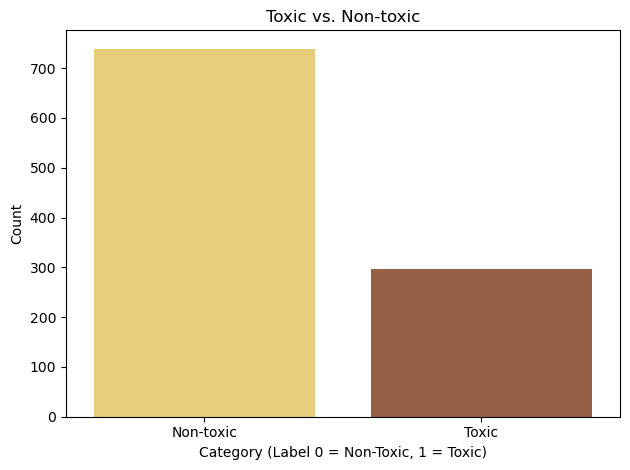

In [13]:
# Show imbalance in label
bee_colors = ['#FAD66B', '#A35A36']  # Non-toxic, Toxic


sns.countplot(data=df, x="label", palette=bee_colors)

plt.title("Toxic vs. Non-toxic")
plt.xticks([0, 1], ['Non-toxic', 'Toxic'])
plt.ylabel("Count")
plt.xlabel("Category (Label 0 = Non-Toxic, 1 = Toxic)")
plt.tight_layout()
plt.show()

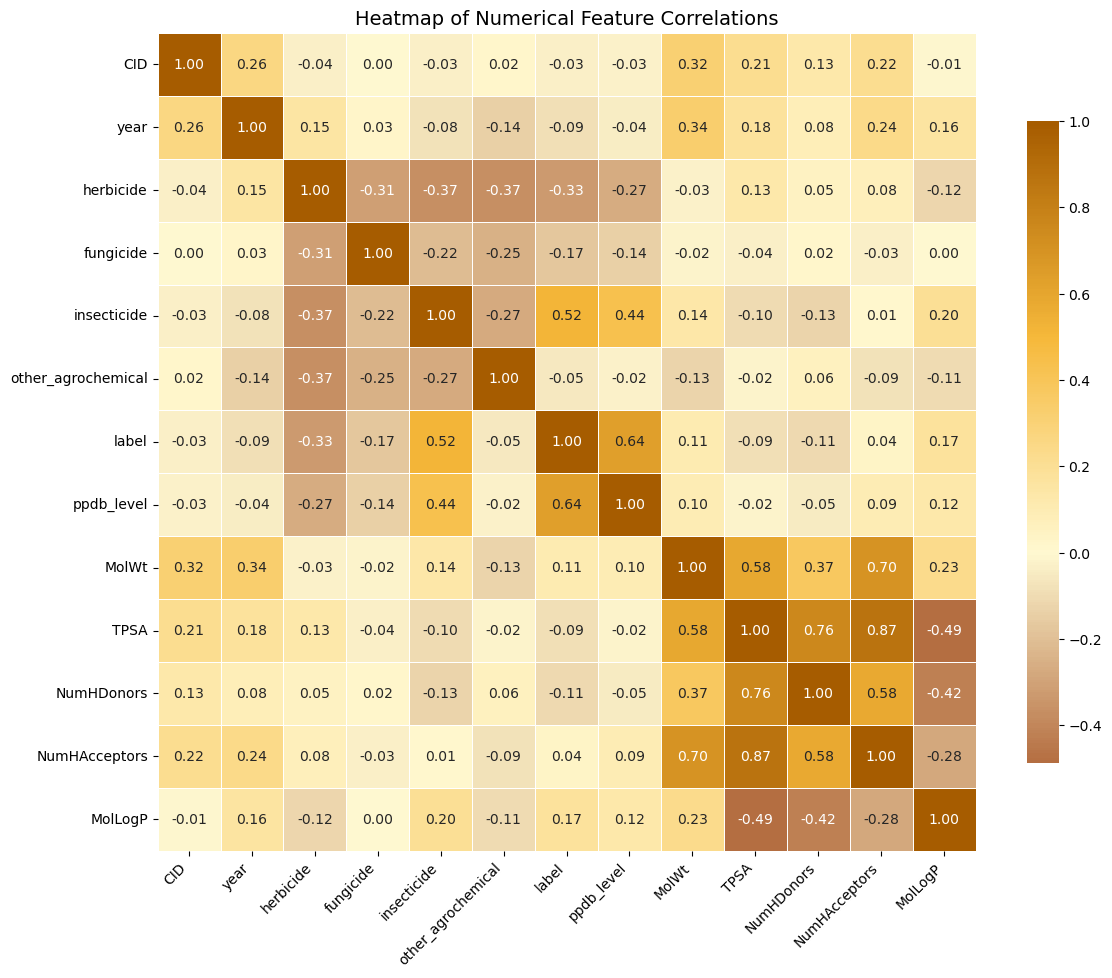

In [14]:
from matplotlib.colors import LinearSegmentedColormap

# Set colors
bee_strong_contrast = [
    "#6B3E26",
    "#B36B3E",
    "#FFF9D1",
    "#F6B93B",
    "#A65C00",
]

# Make heatmap
bee_cmap_strong = LinearSegmentedColormap.from_list("bee_strong_contrast", bee_strong_contrast, N=256)

num_cols = df.select_dtypes(include='number')

corr = num_cols.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap=bee_cmap_strong,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75}
)
plt.title('Heatmap of Numerical Feature Correlations', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

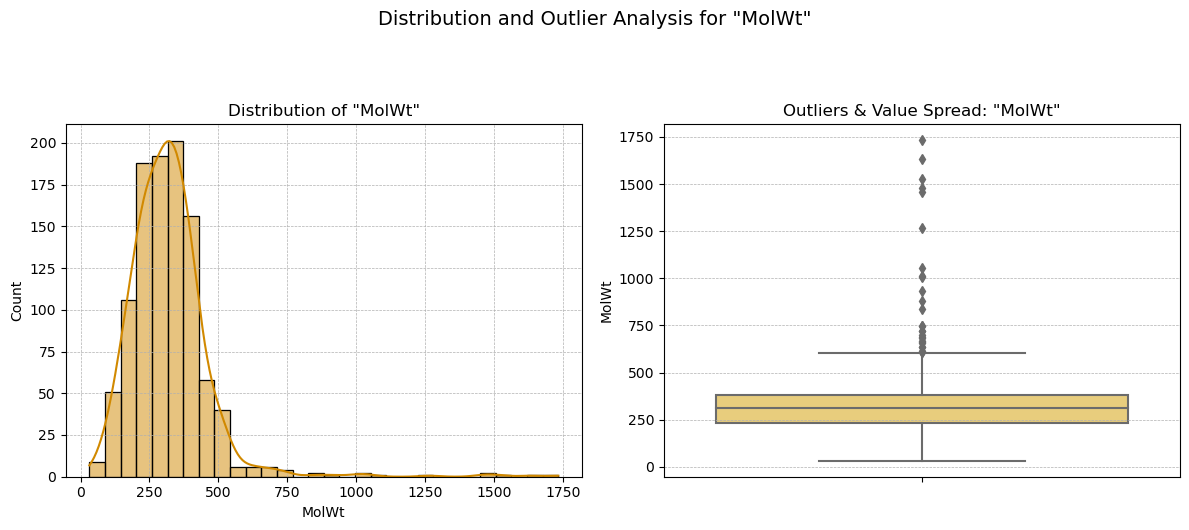

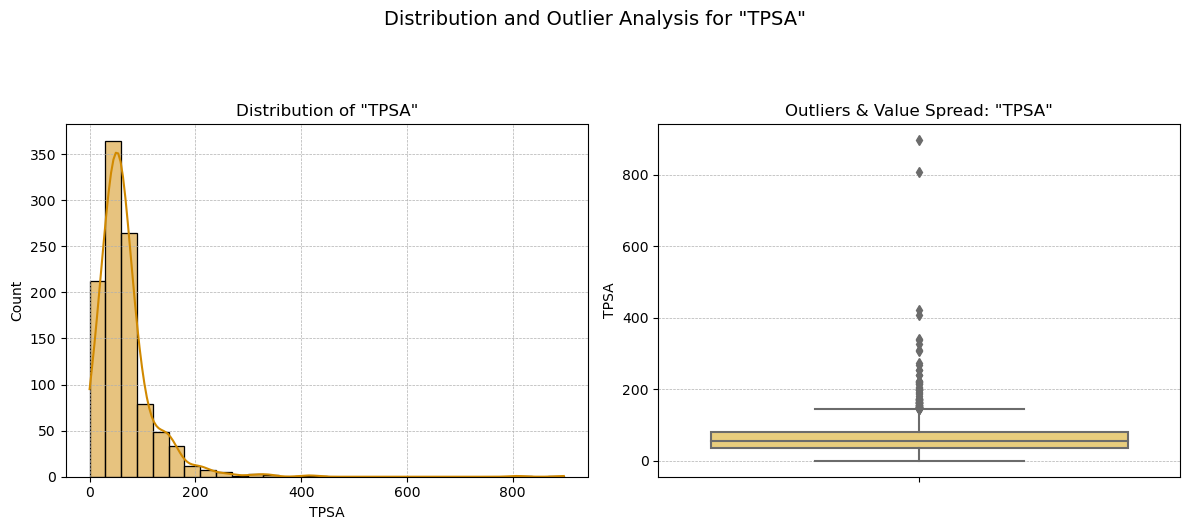

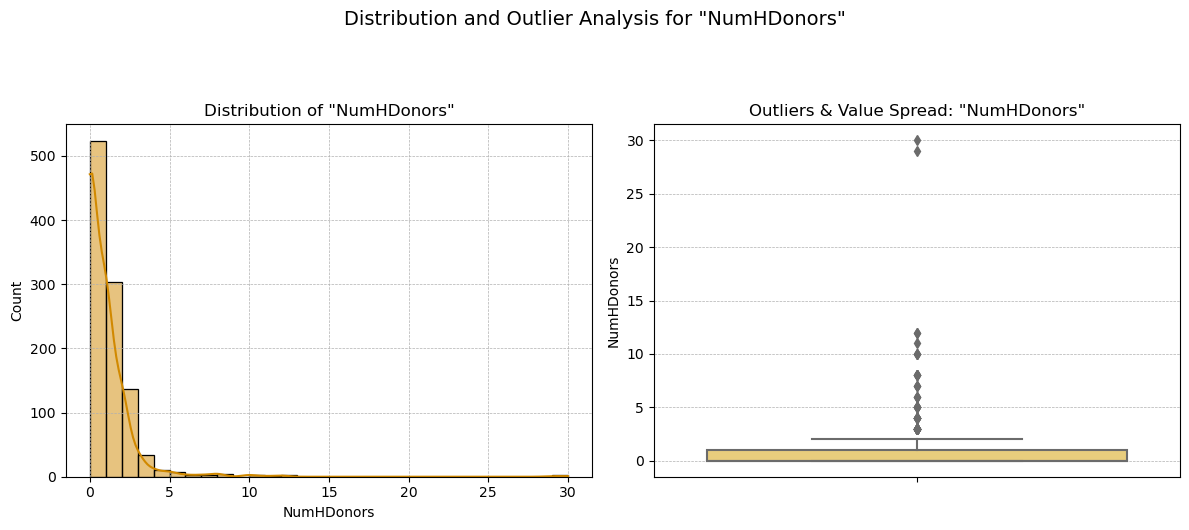

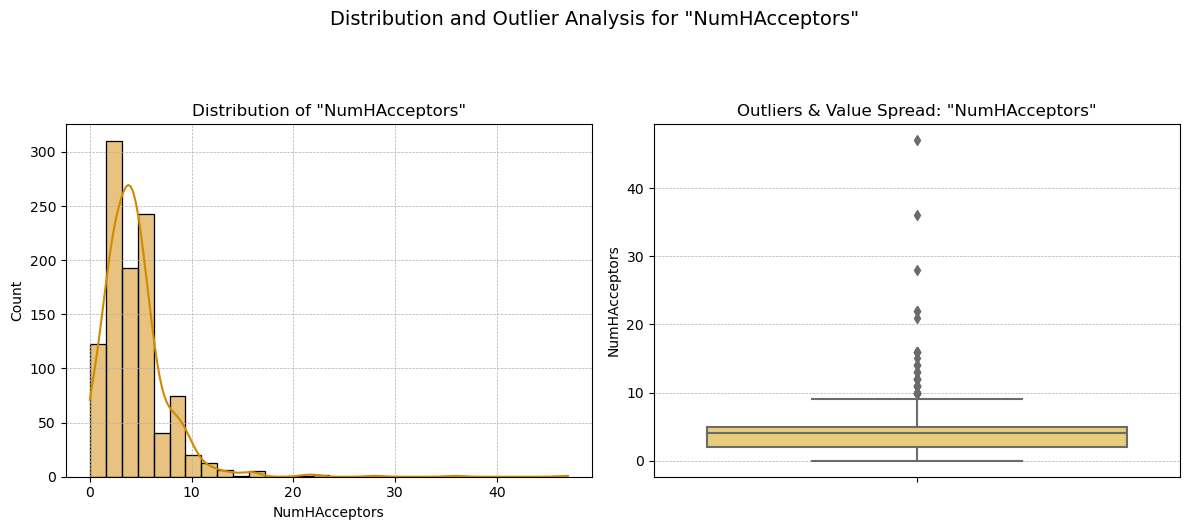

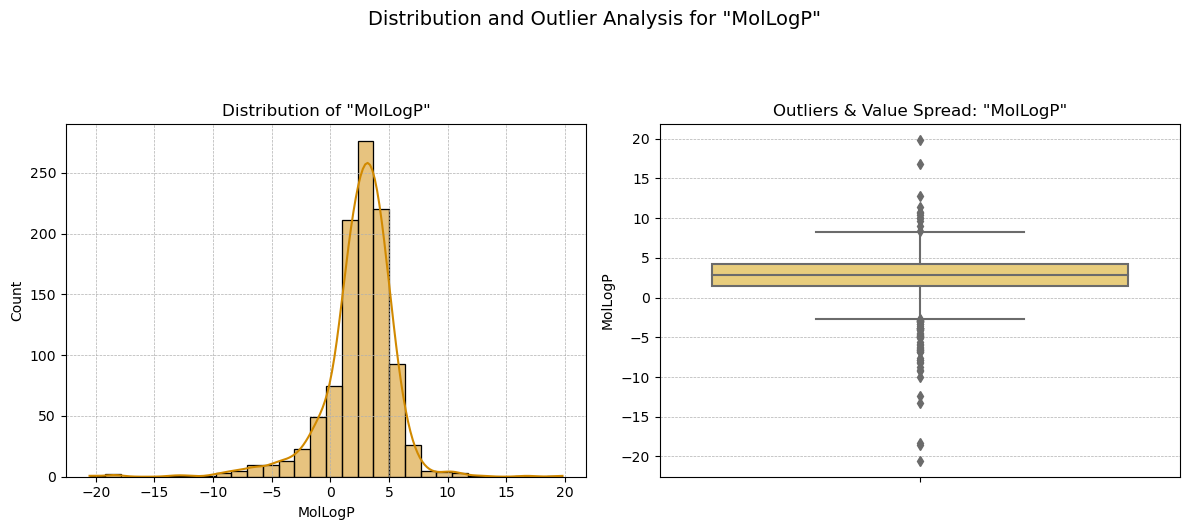

<Figure size 640x480 with 0 Axes>

In [15]:
import math

# Get newly added features
numerical_cols = ['MolWt', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'MolLogP']

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

# Make plot
for i, col in enumerate(numerical_cols):
    plt.figure(figsize=(12, 5))

    # histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col].dropna(), kde=True, color=hist_color, bins=30)
    plt.title(f'Distribution of "{col}"')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(True, linestyle='--', linewidth=0.5)

    # boxplot & outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col].dropna(), color=box_color)
    plt.title(f'Outliers & Value Spread: "{col}"')
    plt.ylabel(col)
    plt.grid(True, axis='y', linestyle='--', linewidth=0.5)

    plt.suptitle(f'Distribution and Outlier Analysis for "{col}"', fontsize=14, y=1.05)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

plt.tight_layout()
plt.show()

After performing feature engineering, we visualized the new numerical features (MolWt, TPSA, MolLogP, NumDonors, NumHAcceptors) as seen in the graphs above. However, these outliers are not considered problematic. In chemical datasets, such outliers often represent unique molecular structures, in this case, it can be highly informative for toxicity predictions.  

# MODELLING + EVALUATION

This section includes training and evaluating the model. Evaluation is done using a confusion matrix which records the number of True Positives, True Negatives, False Positives and False Negatives from the prediction and actual label. In a confusion matrix, multiple evaluation metrics can be gained. For example, the most common metrics used are accuracy and f1-score. For this evaluation, we are using lowest f1-score as the target variable 'label' is imbalanced. These metrics are gained using the function classification_report from sklearn.metrics library. A ROC-Curve is also made to evaluate the general performance of each model.

Hyperparameter tuning is also done using grid search for all the models. The evaluation of the best model as well as their best parameters are stated below.

In [16]:
# dropping unused columns
df = df.drop(['name', 'CID', 'CAS', 'source', 'year', 'ppdb_level'], axis=1)

In [17]:
# split data to train and test
X = df.drop(columns=['label'], axis = 1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 21)

# scaling x
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### RANDOM FOREST

In [18]:
rf = RandomForestClassifier(random_state = 21)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Confusion Matrix:
[[200  22]
 [ 31  58]]
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       222
           1       0.72      0.65      0.69        89

    accuracy                           0.83       311
   macro avg       0.80      0.78      0.78       311
weighted avg       0.83      0.83      0.83       311



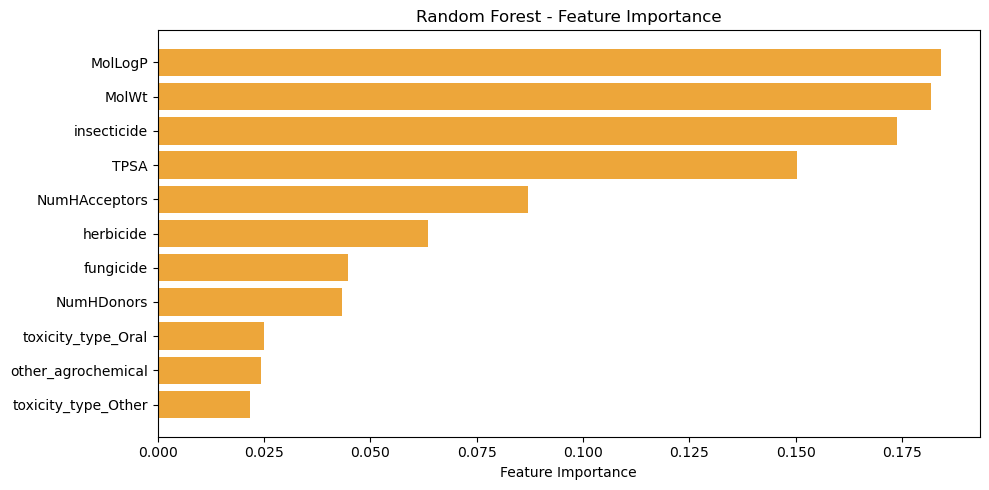

In [19]:
importances = rf.feature_importances_
feature_names = X.columns
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.barh(range(len(importances)), importances[sorted_idx], color= "#EDA63A")
plt.yticks(range(len(importances)), [feature_names[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Random Forest - Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [20]:
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 4, 5],
    'max_features': ['sqrt', 'log2'],
    'random_state': [21]
}

# GridSearchCV with scoring based on F1
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit on training data
grid.fit(X_train, y_train)

# Best model
best_rf = grid.best_estimator_
print("Best parameters:", grid.best_params_)

# Evaluate
y_pred = best_rf.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100, 'random_state': 21}

Confusion Matrix:
[[207  15]
 [ 39  50]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.93      0.88       222
           1       0.77      0.56      0.65        89

    accuracy                           0.83       311
   macro avg       0.81      0.75      0.77       311
weighted avg       0.82      0.83      0.82       311



### LOGISTIC REGRESSION

In [21]:
lr = LogisticRegression(random_state = 21)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[200  22]
 [ 35  54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.88       222
           1       0.71      0.61      0.65        89

    accuracy                           0.82       311
   macro avg       0.78      0.75      0.76       311
weighted avg       0.81      0.82      0.81       311



In [22]:
param_grid = [
    {'penalty':['l1','l2','none'],
    'C' : [0.01, 0.1, 1],
    'solver': ['lbfgs','newton-cg'],
    'max_iter'  : [500, 300],
    'random_state': [21]
}
]

grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring='f1'
)

# Fit on training data
grid.fit(X_train, y_train)

# Best model
best_lr = grid.best_estimator_
print("Best parameters:", grid.best_params_)

# Evaluate
y_pred = best_lr.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))
# Scroll all the way down to see report

C:\Users\aaron\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
C:\Users\aaron\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\aaron\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
C:\Users\aaron\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\aaron\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the

Best parameters: {'C': 0.01, 'max_iter': 500, 'penalty': 'none', 'random_state': 21, 'solver': 'lbfgs'}

Confusion Matrix:
[[200  22]
 [ 36  53]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       222
           1       0.71      0.60      0.65        89

    accuracy                           0.81       311
   macro avg       0.78      0.75      0.76       311
weighted avg       0.81      0.81      0.81       311



C:\Users\aaron\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:952: UserWarning: One or more of the test scores are non-finite: [       nan        nan 0.6318259  0.6318259  0.66630072 0.66630072
        nan        nan 0.6318259  0.6318259  0.66630072 0.66630072
        nan        nan 0.64675428 0.64675428 0.66630072 0.66630072
        nan        nan 0.64675428 0.64675428 0.66630072 0.66630072
        nan        nan 0.66284871 0.66284871 0.66630072 0.66630072
        nan        nan 0.66284871 0.66284871 0.66630072 0.66630072]
  warnings.warn(
C:\Users\aaron\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
C:\Users\aaron\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


### DECISION TREE

In [23]:
tree = DecisionTreeClassifier(random_state = 21)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[183  39]
 [ 41  48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       222
           1       0.55      0.54      0.55        89

    accuracy                           0.74       311
   macro avg       0.68      0.68      0.68       311
weighted avg       0.74      0.74      0.74       311



In [24]:
param_grid = {
    'max_depth': [10, 20, 5],
    'min_samples_split': [2, 4, 5],
    'min_samples_leaf': [4, 2, 3],
    'random_state' : [21]
}

# GridSearchCV with scoring based on F1
grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring='f1',
    verbose=1
)

# Fit on training data
grid.fit(X_train, y_train)

# Best model
best_tree = grid.best_estimator_
print("Best parameters:", grid.best_params_)

# Evaluate
y_pred = best_tree.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'random_state': 21}

Confusion Matrix:
[[198  24]
 [ 40  49]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       222
           1       0.67      0.55      0.60        89

    accuracy                           0.79       311
   macro avg       0.75      0.72      0.73       311
weighted avg       0.79      0.79      0.79       311



### SVM

In [25]:
svm = SVC(probability=True, random_state = 21)

svm.fit(X_train,y_train)

y_pred = svm.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[198  24]
 [ 34  55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       222
           1       0.70      0.62      0.65        89

    accuracy                           0.81       311
   macro avg       0.77      0.75      0.76       311
weighted avg       0.81      0.81      0.81       311



In [26]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'random_state' : [21]
}

grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='f1',
    verbose=1
)

# Fit on training data
grid.fit(X_train, y_train)

# Best model
best_svm = grid.best_estimator_
print("Best parameters:", grid.best_params_)

# Evaluate
y_pred = best_svm.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear', 'random_state': 21}

Confusion Matrix:
[[195  27]
 [ 33  56]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       222
           1       0.67      0.63      0.65        89

    accuracy                           0.81       311
   macro avg       0.76      0.75      0.76       311
weighted avg       0.80      0.81      0.80       311



### K-NEAREST NEIGHBOR

In [27]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[199  23]
 [ 32  57]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       222
           1       0.71      0.64      0.67        89

    accuracy                           0.82       311
   macro avg       0.79      0.77      0.78       311
weighted avg       0.82      0.82      0.82       311



In [28]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='f1',
    verbose=1
)

# Fit on training data
grid.fit(X_train, y_train)

# Best model
best_knn = grid.best_estimator_
print("Best parameters:", grid.best_params_)

# Evaluate
y_pred = best_knn.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}

Confusion Matrix:
[[199  23]
 [ 29  60]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       222
           1       0.72      0.67      0.70        89

    accuracy                           0.83       311
   macro avg       0.80      0.79      0.79       311
weighted avg       0.83      0.83      0.83       311



### XG BOOST

In [29]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state = 21)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[197  25]
 [ 34  55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       222
           1       0.69      0.62      0.65        89

    accuracy                           0.81       311
   macro avg       0.77      0.75      0.76       311
weighted avg       0.81      0.81      0.81       311



C:\Users\aaron\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:05:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### BAGGING

In [30]:
bagging = BaggingClassifier(estimator=best_knn, random_state = 21)

bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[200  22]
 [ 31  58]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       222
           1       0.72      0.65      0.69        89

    accuracy                           0.83       311
   macro avg       0.80      0.78      0.78       311
weighted avg       0.83      0.83      0.83       311



### SOFT VOTING

In [31]:
# soft voting
estimators = [('LR', best_lr),
              ('KNN', best_knn),
              ('RF', best_rf),
              ('SVM', best_svm),
              ('XGB', xgb),
              ]

voting_model = VotingClassifier(estimators = estimators, voting='soft')

voting_model.fit(X_train, y_train)

pred = voting_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))

print("\nClassification Report:")
print(classification_report(y_test, pred))

C:\Users\aaron\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
C:\Users\aaron\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\aaron\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:05:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion Matrix:
[[206  16]
 [ 35  54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       222
           1       0.77      0.61      0.68        89

    accuracy                           0.84       311
   macro avg       0.81      0.77      0.78       311
weighted avg       0.83      0.84      0.83       311



### HARD VOTING

In [32]:
# hard voting
estimators = [('LR', best_lr),
              ('KNN', best_knn),
              ('RF', best_rf),
              ('SVM', best_svm),
              ('XGB', xgb),
              ]

voting_model = VotingClassifier(estimators = estimators, voting='hard')

voting_model.fit(X_train, y_train)

pred = voting_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))

print("\nClassification Report:")
print(classification_report(y_test, pred))

C:\Users\aaron\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1173: FutureWarning: `penalty='none'`has been deprecated in 1.2 and will be removed in 1.4. To keep the past behaviour, set `penalty=None`.
  warnings.warn(
C:\Users\aaron\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\aaron\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:05:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion Matrix:
[[202  20]
 [ 34  55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       222
           1       0.73      0.62      0.67        89

    accuracy                           0.83       311
   macro avg       0.79      0.76      0.78       311
weighted avg       0.82      0.83      0.82       311



### ADABOOST

In [33]:
ada = AdaBoostClassifier(estimator = best_rf, random_state = 21)

ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[197  25]
 [ 31  58]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       222
           1       0.70      0.65      0.67        89

    accuracy                           0.82       311
   macro avg       0.78      0.77      0.77       311
weighted avg       0.82      0.82      0.82       311



# SUMMARY MODELS

This section contains the summary of scores for all the models. The ROC Curve for all models is also here.

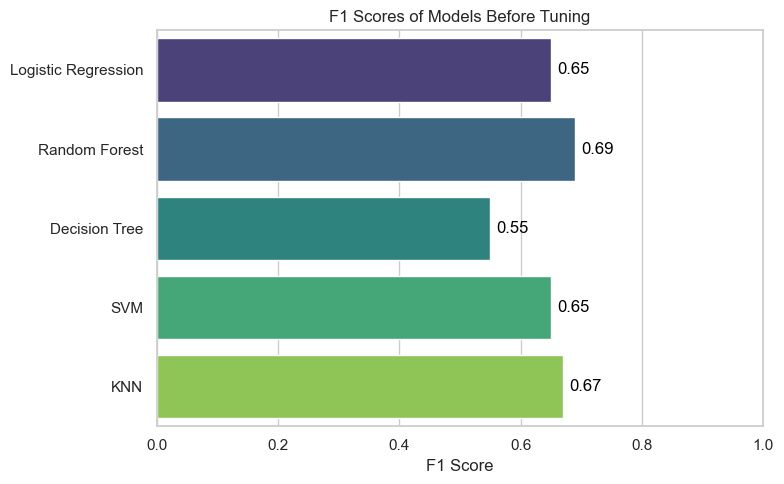

In [34]:
# before tuning

# Get scores
models = ['Logistic Regression', 'Random Forest', 'Decision Tree', 'SVM', 'KNN']
f1_scores = [0.65, 0.69, 0.55, 0.65, 0.67]

# Plot scores
plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")
barplot = sns.barplot(x=f1_scores, y=models, palette="viridis")

for i, score in enumerate(f1_scores):
    plt.text(score + 0.01, i, f"{score:.2f}", color='black', va='center')

plt.xlabel("F1 Score")
plt.title("F1 Scores of Models Before Tuning")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

Before tuning, we could see that random forest has the highest f1-score with 0.69. On the other hand, decision tree has the lowest f1-score with 0.55.

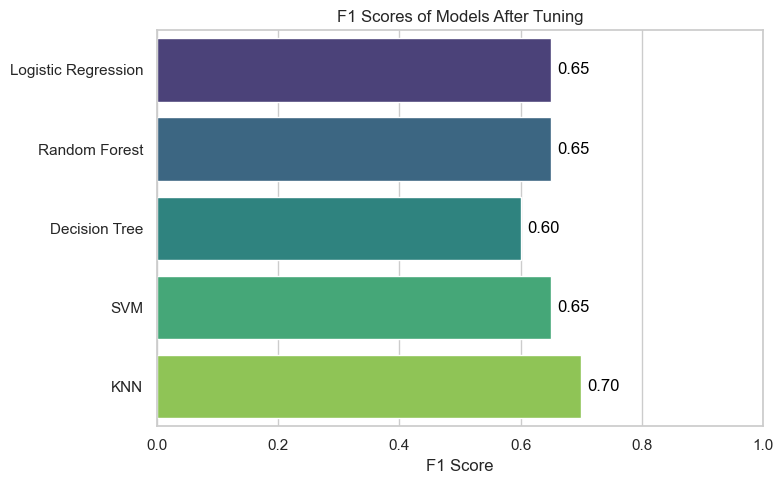

In [35]:
# after tuning

# Get scores
models = ['Logistic Regression', 'Random Forest', 'Decision Tree', 'SVM', 'KNN']
f1_scores = [0.65, 0.65, 0.60, 0.65, 0.70]

# Plot scores
plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")
barplot = sns.barplot(x=f1_scores, y=models, palette="viridis")

for i, score in enumerate(f1_scores):
    plt.text(score + 0.01, i, f"{score:.2f}", color='black', va='center')

plt.xlabel("F1 Score")
plt.title("F1 Scores of Models After Tuning")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

After tuning, we could see that the f1-score for random forest dropped to 0.65. The highest f1-score this time is from KNN with 0.70. The f1-score for decision tree rises to 0.69, however, it is still the lowest f1-score.

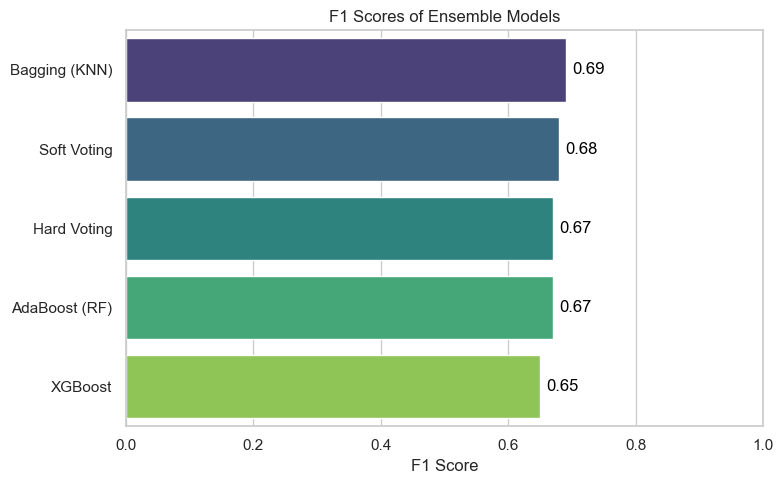

In [36]:
# ensemble

# Get scores
models = ['Bagging (KNN)', 'Soft Voting', 'Hard Voting', 'AdaBoost (RF)', 'XGBoost']
f1_scores = [0.69, 0.68, 0.67, 0.67, 0.65]

# Plot scores
plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")
barplot = sns.barplot(x=f1_scores, y=models, palette="viridis")

for i, score in enumerate(f1_scores):
    plt.text(score + 0.01, i, f"{score:.2f}", color='black', va='center')

plt.xlabel("F1 Score")
plt.title("F1 Scores of Ensemble Models")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

For ensemble models, the highest f1-score is bagging using KNN with 0.69. On the other hand, the lowest f1-score is XGBoost with 0.65.

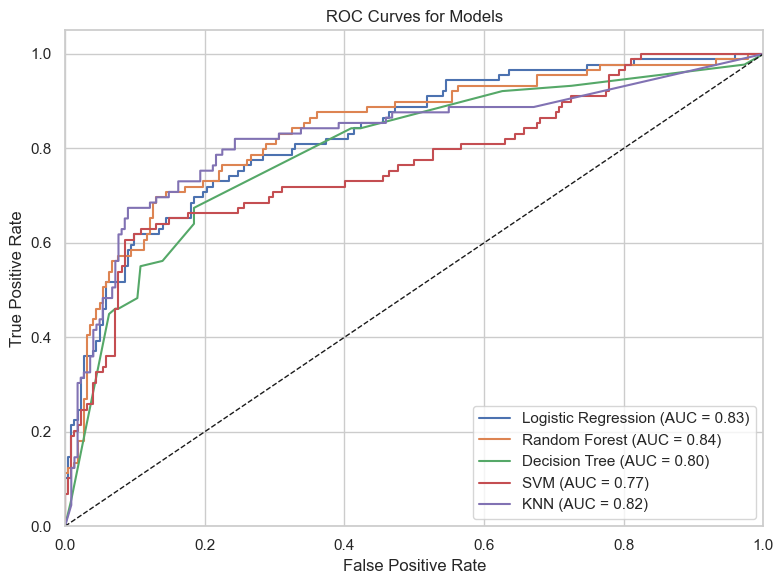

In [37]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get best models
models = {
    'Logistic Regression': best_lr,
    'Random Forest': best_rf,
    'Decision Tree': best_tree,
    'SVM': best_svm,
    'KNN': best_knn
}

plt.figure(figsize=(8, 6))

# Plot ROC Curve
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        y_probs = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')


plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


From the ROC curves, we can see that random forest has the highest overall performance with 0.84 while SVM has the lowest overall performance with 0.77.

From the evaluations above we can conclude that KNN is able to identify whether a chemical is toxic despite class imbalance better than other models. However, in terms of overall performance, random forest has the highest AUC score than the other models.